# Prédiction des Résultats Médicaux
### EHTP MSDE - 2025/2026 - Projet réalisé par Mr.SAID EL YAZAMI

## 1. Introduction
L'objectif de ce projet est de construire un modèle de machine learning capable de prédire le résultat d'un test médical (Normal, Abnormal, Inconclusive) en fonction des caractéristiques démographiques et cliniques des patients hospitalisés.

## 2. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

## 3. Chargement et Exploration des Données

In [2]:
df = pd.read_csv('healthcare_dataset.csv')
print("Aperçu des données :")
display(df.head())
print("\nInformations sur le dataset :")
df.info()

Aperçu des données :


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2

## 4. Analyse Exploratoire des Données (EDA)
Visualisation de la distribution de la variable cible et des relations entre les caractéristiques.

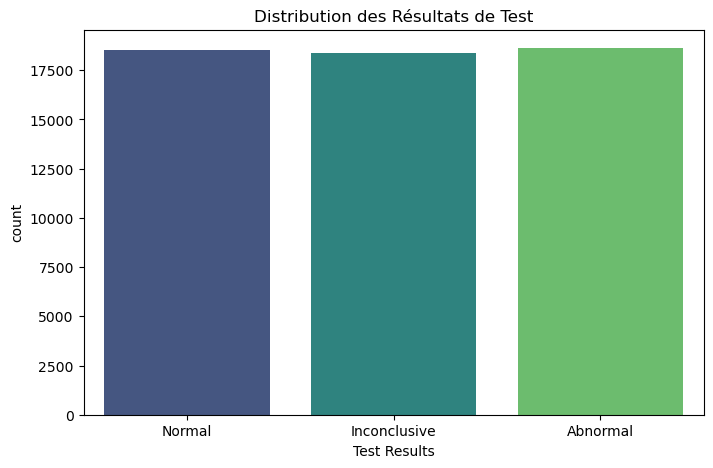

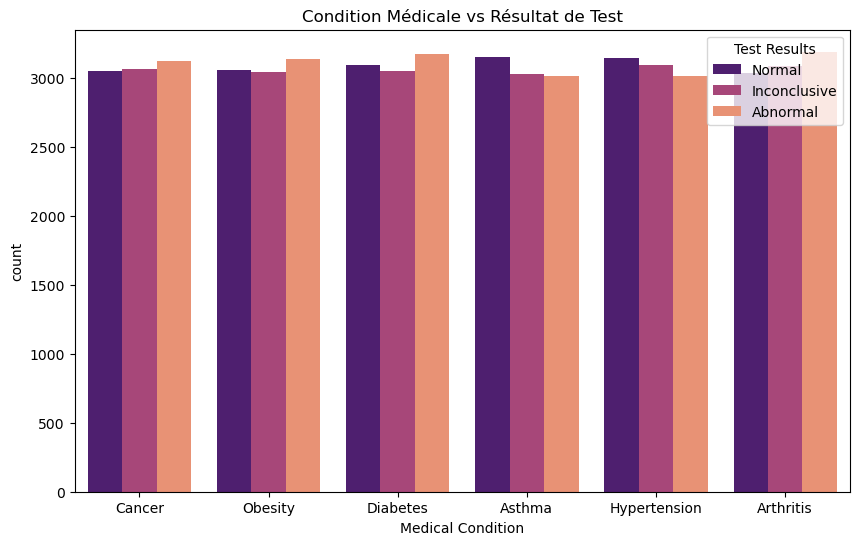

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Test Results', palette='viridis')
plt.title('Distribution des Résultats de Test')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Medical Condition', hue='Test Results', palette='magma')
plt.title('Condition Médicale vs Résultat de Test')
plt.show()

## 5. Prétraitement des Données
- Suppression des colonnes inutiles.
- Conversion des dates.
- Calcul de la durée d'hospitalisation.
- Encodage des variables catégorielles.

In [4]:
# Suppression des colonnes non pertinentes
df_clean = df.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number'])

# Traitement des dates
df_clean['Date of Admission'] = pd.to_datetime(df_clean['Date of Admission'])
df_clean['Discharge Date'] = pd.to_datetime(df_clean['Discharge Date'])
df_clean['Days_Hospitalized'] = (df_clean['Discharge Date'] - df_clean['Date of Admission']).dt.days
df_clean = df_clean.drop(columns=['Date of Admission', 'Discharge Date'])

# Encodage
cat_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

le_target = LabelEncoder()
df_clean['Test Results'] = le_target.fit_transform(df_clean['Test Results'])

df_clean.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Days_Hospitalized
0,30,1,5,2,1,18856.281306,2,3,2,2
1,62,1,0,5,3,33643.327287,1,1,1,6
2,76,0,1,5,0,27955.096079,1,0,2,15
3,28,0,6,3,3,37909.782410,0,1,0,30
4,43,0,2,2,0,14238.317814,2,4,0,20


## 6. Construction du Modèle
Utilisation d'un Random Forest pour la classification multi-classe.

In [5]:
X = df_clean.drop(columns=['Test Results'])
y = df_clean['Test Results']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Évaluation des Résultats

Précision globale : 0.44

Rapport de classification :
              precision    recall  f1-score   support

    Abnormal       0.44      0.45      0.44      3754
Inconclusive       0.43      0.42      0.43      3617
      Normal       0.45      0.44      0.44      3729

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



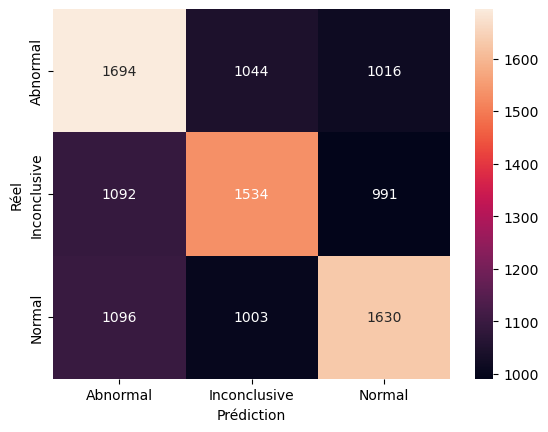

In [6]:
y_pred = model.predict(X_test_scaled)
print(f"Précision globale : {accuracy_score(y_test, y_pred):.2f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.show()